In [2]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [4]:
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [6]:
df[['job_title_short', 'job_skills']].head()

,job_title_short,job_skills
0,Senior Data Engineer,NaN
1,Data Analyst,"[r, python, sql, nosql, power bi, tableau]"
2,Data Engineer,"[python, sql, c#, azure, airflow, dax, docker,..."
3,Data Engineer,"[python, c++, java, matlab, aws, tensorflow, k..."
4,Data Engineer,"[bash, python, oracle, aws, ansible, puppet, j..."


In [7]:
help(df.explode)

Help on method explode in module pandas.core.frame:

explode(column: 'IndexLabel', ignore_index: 'bool' = False) -> 'DataFrame' method of pandas.DataFrame instance
    Transform each element of a list-like to a row, replicating index values.
    
    Parameters
    ----------
    column : IndexLabel
        Column(s) to explode.
        For multiple columns, specify a non-empty list with each element
        be str or tuple, and all specified columns their list-like data
        on same row of the frame must have matching length.
    
    ignore_index : bool, default False
        If True, the resulting index will be labeled 0, 1, …, n - 1.
    
    Returns
    -------
    DataFrame
        Exploded lists to rows of the subset columns;
        index will be duplicated for these rows.
    
    Raises
    ------
    ValueError :
        * If columns of the frame are not unique.
        * If specified columns to explode is empty list.
        * If specified columns to explode have not mat

In [9]:
df_exploded = df.explode('job_skills')

<Axes: xlabel='job_skills'>

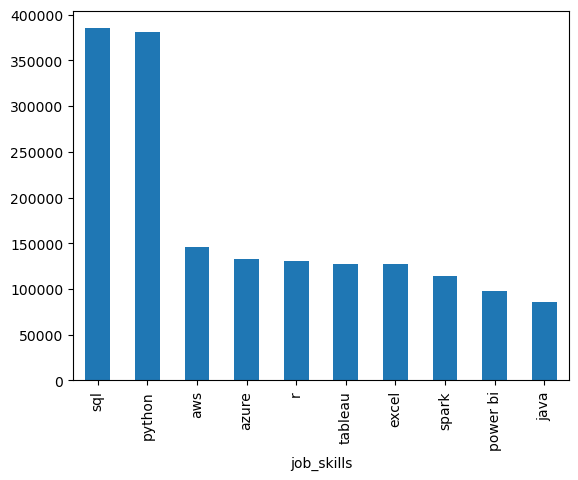

In [12]:
df_exploded['job_skills'].value_counts().head(10).plot(kind = 'bar')

In [15]:
skills_counts = df_exploded.groupby(['job_title_short', 'job_skills']).size()

type(skills_counts)

pandas.Series

In [20]:
df_skills_count = skills_counts.reset_index(name = 'skill_count')

df_skills_count = df_skills_count.sort_values(by = 'skill_count', ascending = False)

df_skills_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


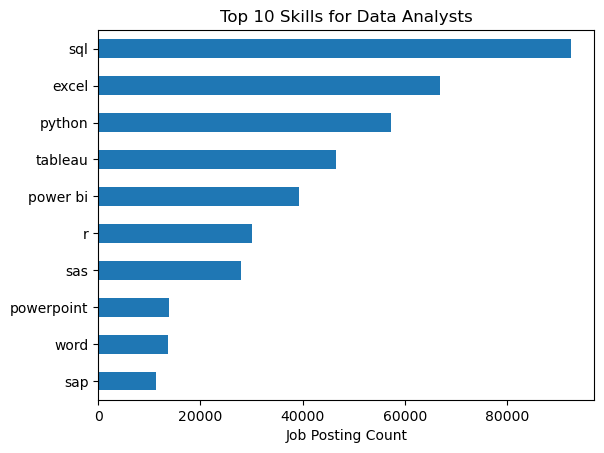

In [27]:
job_title = 'Data Analyst'
top_skills = 10

df_skill_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skills)

df_skill_final.plot(kind = 'barh', x = 'job_skills', y = 'skill_count')
plt.gca().invert_yaxis()
plt.title(f'Top {top_skills} Skills for {job_title}s')
plt.xlabel('Job Posting Count')
plt.ylabel('')
plt.legend().set_visible(False)
plt.show()


## Again

In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [2]:
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [3]:
df_exploded = df.explode('job_skills')

<Axes: xlabel='job_skills'>

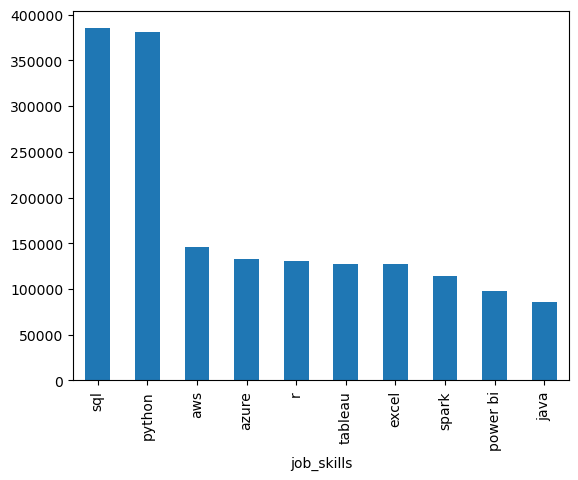

In [5]:
df_exploded['job_skills'].value_counts().head(10).plot(kind = 'bar')

In [8]:
skills_count = df_exploded.groupby(['job_title_short', 'job_skills']).size()
skills_count

job_title_short    job_skills
Business Analyst   airflow        318
                   airtable        17
                   alteryx       1078
                   angular         87
                   ansible        120
                                 ... 
Software Engineer  wrike            4
                   wsl             13
                   xamarin         35
                   yarn           145
                   zoom           229
Length: 2256, dtype: int64

In [11]:
df_skills_count = skills_count.reset_index(name = 'skill_count')
df_skills_count

,job_title_short,job_skills,skill_count
0,Business Analyst,airflow,318
1,Business Analyst,airtable,17
2,Business Analyst,alteryx,1078
3,Business Analyst,angular,87
4,Business Analyst,ansible,120
...,...,...,...
2251,Software Engineer,wrike,4
2252,Software Engineer,wsl,13
2253,Software Engineer,xamarin,35
2254,Software Engineer,yarn,145


In [15]:
df_skills_count = df_skills_count.sort_values(by = 'skill_count', ascending = False)

In [16]:
job_title = 'Data Analyst'
head_value = 10

df_skill_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(head_value)
df_skill_final

,job_title_short,job_skills,skill_count
625,Data Analyst,sql,92428
494,Data Analyst,excel,66860
590,Data Analyst,python,57190
638,Data Analyst,tableau,46455
583,Data Analyst,power bi,39380
594,Data Analyst,r,29996
606,Data Analyst,sas,27998
585,Data Analyst,powerpoint,13822
664,Data Analyst,word,13562
605,Data Analyst,sap,11280


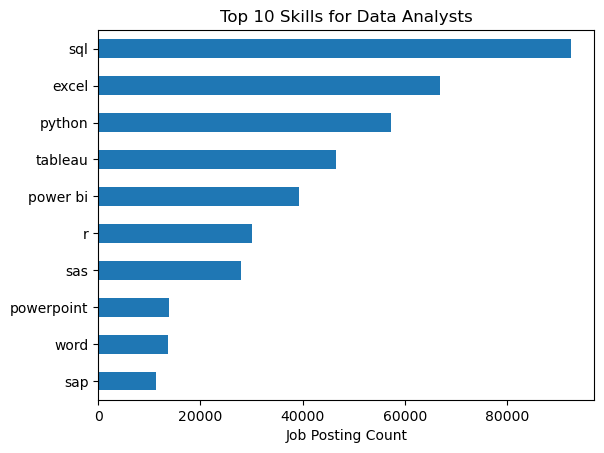

In [20]:
df_skill_final.plot(kind = 'barh', x = 'job_skills', y = 'skill_count')
plt.xlabel('Job Posting Count')
plt.ylabel('')
plt.title(f'Top {head_value} Skills for {job_title}s')
plt.gca().invert_yaxis()
plt.legend().set_visible(False)
plt.show()

## Problem

In [2]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [3]:
import ast

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [4]:
df_exploded = df.explode('job_skills')

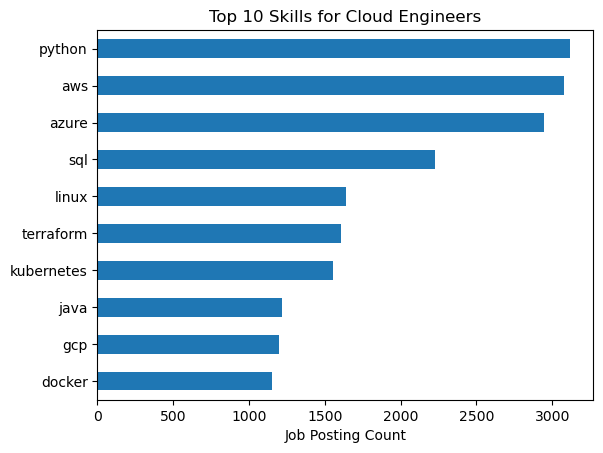

In [6]:
df_cloud = df_exploded[df_exploded['job_title_short'] == 'Cloud Engineer']

top_skills = df_cloud['job_skills'].value_counts().head(10)

top_skills.plot(kind = 'barh')
plt.title('Top 10 Skills for Cloud Engineers')
plt.xlabel('Job Posting Count')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.show()

In [7]:
df_salary = df_exploded.dropna(subset = 'salary_year_avg')

In [9]:
salary_by_skill = df_salary.groupby('job_skills')['salary_year_avg'].mean()
salary_by_skill

job_skills
airflow       142255.967200
airtable      140615.340909
alteryx       112911.989678
angular       126330.310426
angular.js    127050.000000
                  ...      
workfront      97673.763672
wrike         101250.000000
xamarin       121250.000000
yarn          111970.011239
zoom          127276.297468
Name: salary_year_avg, Length: 219, dtype: float64

In [11]:
top_salary = salary_by_skill.sort_values(ascending=False).head(10)
top_salary

job_skills
debian          196500.000000
ringcentral     182500.000000
lua             170500.000000
mongo           169526.929749
dplyr           160667.210526
watson          157102.290323
node            156697.295455
haskell         155757.666667
asp.net core    155000.000000
solidity        153639.950000
Name: salary_year_avg, dtype: float64

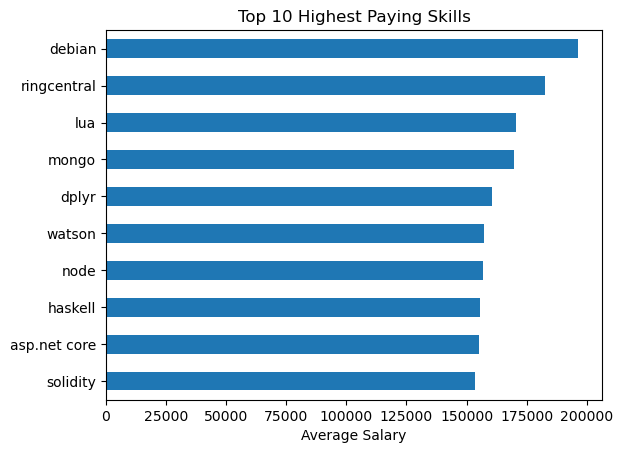

In [13]:
top_salary.plot(kind = 'barh')
plt.title('Top 10 Highest Paying Skills')
plt.xlabel('Average Salary')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.show()

In [14]:
uninque_skills = df_exploded['job_skills'].nunique()

uninque_skills

252